In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Data faylı bu notebook ilə eyni qovluqda olmalıdır (bax: README.md)
# Mənbə: https://www.kaggle.com/datasets/shivamb/netflix-shows
df = pd.read_csv("netflix_titles.csv")
df

## INFO

In [3]:
# show_id      -> hər film/TV show üçün unikal ID (məs: s1, s2)
# type         -> məzmun növü: Movie (film) və ya TV Show (serial)
# title        -> film və ya serialın adı
# director     -> rejissorun adı
# cast         -> aktyorlar siyahısı
# country      -> istehsal olunduğu ölkə
# date_added   -> Netflix-ə əlavə olunma tarixi
# release_year -> filmin/serialın çıxış ili
# rating       -> yaş reytinqi (PG, TV-MA və s.)
# duration     -> müddət (film: dəqiqə, serial: sezon sayı)
# listed_in    -> janr (Drama, Comedy və s.)
# description  -> filmin qısa məzmunu

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df["director"] = df["director"].fillna("Not Specified")
df["cast"] = df["cast"].fillna("Unknown")

## Date_added

## Insight

`date_added` sütunundakı missing values təmizləndikdən sonra uyğunsuzluq analizi aparıldı. Analiz nəticəsində dataset-də 14 uyğunsuz sətir aşkar edildi.

Bu sətirlərdə Netflix-ə əlavə olunma ili (`date_added` sütunundan çıxarılan `added_year`) content-in çıxış ilindən (`release_year`) kiçikdir. Normalda əlavə olunma ili çıxış ilinə bərabər və ya ondan böyük olmalıdır.

Uyğunsuzluqların böyük hissəsi TV Show-lara aiddir. Bu, çox güman ki, serialların sezonlar üzrə yenilənməsi (yəni yeni sezonların fərqli illərdə yayımlanması) və ya metadata-nın tam düzgün saxlanmaması ilə əlaqədardır.

Movie-lərdə bu cür hallar çox az müşahidə olunur. Bu da filmlərin adətən yalnız bir dəfə yayımlanması və sabit `release_year` dəyərinə malik olması ilə izah edilə bilər.

Qrafik göstərir ki, Netflix-ə əlavə olunan məzmunun sayı 2016-cı ildən sonra sürətlə artmış və 2019-cu ildə pik həddə çatmışdır. Bütün illər üzrə Movie kateqoriyası TV Show kateqoriyasından daha çox üstünlük təşkil edir, lakin 2020–2021-ci illərdə əlavə olunan məzmunun sayında azalma müşahidə olunur.

In [10]:
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(),errors="coerce")

In [11]:
df["date_added"].isna().sum()

np.int64(10)

In [12]:
df[df["date_added"].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,Not Specified,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,Not Specified,Anthony Bourdain,United States,NaT,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,Not Specified,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaT,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,Not Specified,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaT,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,Not Specified,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaT,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,Not Specified,Igor Dmitriev,NaN,NaT,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,Not Specified,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaT,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,Not Specified,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaT,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,Not Specified,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaT,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,Not Specified,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaT,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [13]:
df.dropna(subset=["date_added"], inplace=True)

In [14]:
df["date_added"].dtype

dtype('<M8[ns]')

In [15]:
df["added_year"] = pd.to_datetime(df["date_added"]).dt.year

In [16]:
df[df["added_year"] < df["release_year"]]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year
1551,s1552,TV Show,Hilda,Not Specified,"Bella Ramsey, Ameerah Falzon-Ojo, Oliver Nelso...","United Kingdom, Canada, United States",2020-12-14,2021,TV-Y7,2 Seasons,Kids' TV,"Fearless, free-spirited Hilda finds new friend...",2020
1696,s1697,TV Show,Polly Pocket,Not Specified,"Emily Tennant, Shannon Chan-Kent, Kazumi Evans...","Canada, United States, Ireland",2020-11-15,2021,TV-Y,2 Seasons,Kids' TV,After uncovering a magical locket that allows ...,2020
2920,s2921,TV Show,Love Is Blind,Not Specified,"Nick Lachey, Vanessa Lachey",United States,2020-02-13,2021,TV-MA,1 Season,"Reality TV, Romantic TV Shows",Nick and Vanessa Lachey host this social exper...,2020
3168,s3169,TV Show,Fuller House,Not Specified,"Candace Cameron Bure, Jodie Sweetin, Andrea Ba...",United States,2019-12-06,2020,TV-PG,5 Seasons,TV Comedies,The Tanner family’s adventures continue as DJ ...,2019
3287,s3288,TV Show,Maradona in Mexico,Not Specified,Diego Armando Maradona,"Argentina, United States, Mexico",2019-11-13,2020,TV-MA,1 Season,"Docuseries, Spanish-Language TV Shows","In this docuseries, soccer great Diego Maradon...",2019
3369,s3370,TV Show,BoJack Horseman,Not Specified,"Will Arnett, Aaron Paul, Amy Sedaris, Alison B...",United States,2019-10-25,2020,TV-MA,6 Seasons,TV Comedies,Meet the most beloved sitcom horse of the '90s...,2019
3433,s3434,TV Show,The Hook Up Plan,Not Specified,"Marc Ruchmann, Zita Hanrot, Sabrina Ouazani, J...",France,2019-10-11,2020,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...","When Parisian Elsa gets hung up on her ex, her...",2019
4844,s4845,TV Show,Unbreakable Kimmy Schmidt,Not Specified,"Ellie Kemper, Jane Krakowski, Tituss Burgess, ...",United States,2018-05-30,2019,TV-14,4 Seasons,TV Comedies,When a woman is rescued from a doomsday cult a...,2018
4845,s4846,TV Show,Arrested Development,Not Specified,"Jason Bateman, Portia de Rossi, Will Arnett, M...",United States,2018-05-29,2019,TV-MA,5 Seasons,TV Comedies,It's the Emmy-winning story of a wealthy famil...,2018
5394,s5395,Movie,Hans Teeuwen: Real Rancour,Doesjka van Hoogdalem,Hans Teeuwen,Netherlands,2017-07-01,2018,TV-MA,86 min,Stand-Up Comedy,Comedian Hans Teeuwen rebels against political...,2017


In [17]:
df[df["added_year"] < df["release_year"]]["type"].value_counts()

type
TV Show    12
Movie       2
Name: count, dtype: int64

In [18]:
df[(df["added_year"] < df["release_year"]) & (df["type"] == "Movie")][["title", "date_added", "release_year"]]

,title,date_added,release_year
5394,Hans Teeuwen: Real Rancour,2017-07-01,2018
7063,Incoming,2018-10-26,2019


In [19]:
df[(df["added_year"] < df["release_year"]) & (df["type"] == "TV Show")][["title", "date_added", "release_year"]]

,title,date_added,release_year
1551,Hilda,2020-12-14,2021
1696,Polly Pocket,2020-11-15,2021
2920,Love Is Blind,2020-02-13,2021
3168,Fuller House,2019-12-06,2020
3287,Maradona in Mexico,2019-11-13,2020
3369,BoJack Horseman,2019-10-25,2020
3433,The Hook Up Plan,2019-10-11,2020
4844,Unbreakable Kimmy Schmidt,2018-05-30,2019
4845,Arrested Development,2018-05-29,2019
5658,Sense8,2016-12-23,2018


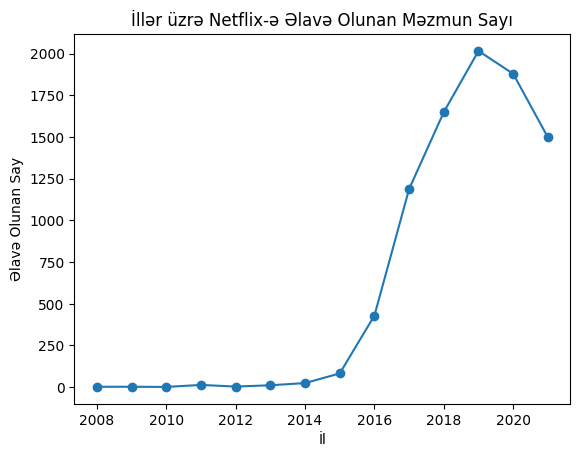

In [20]:
df["added_year"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("İllər üzrə Netflix-ə Əlavə Olunan Məzmun Sayı")
plt.xlabel("İl")
plt.ylabel("Əlavə Olunan Say")
plt.show()

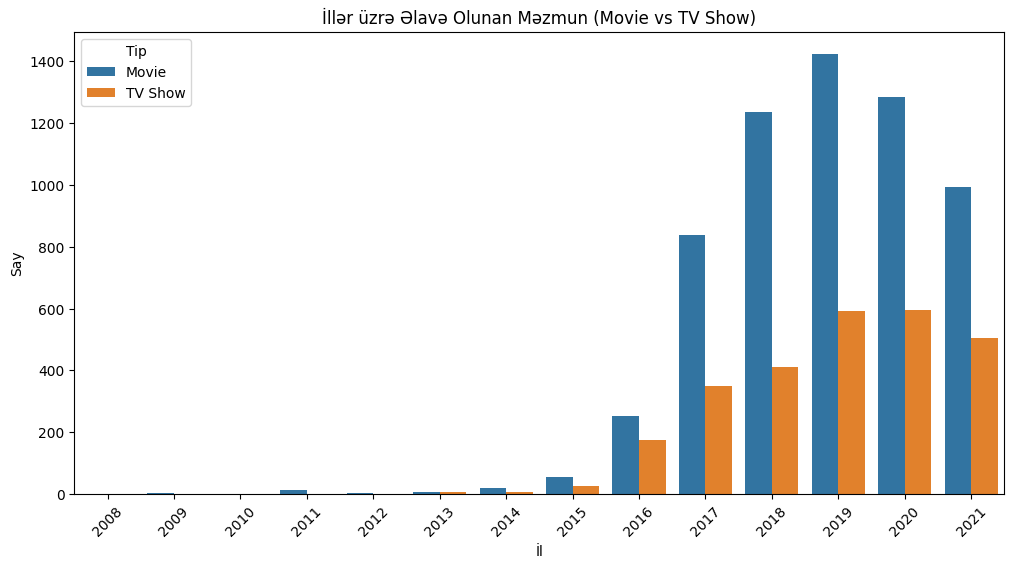

In [21]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="added_year", hue="type")
plt.title("İllər üzrə Əlavə Olunan Məzmun (Movie vs TV Show)")
plt.xlabel("İl")
plt.ylabel("Say")
plt.xticks(rotation=45)
plt.legend(title="Tip")
plt.show()

## Type

## Insight

Movie-lər dataset-in təxminən 69.7%-ni, TV Show-lar isə 30.3%-ni təşkil edir.
Bu, Netflix-də film məzmununun seriallardan daha çox olduğunu göstərir.

In [22]:
df["type"].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [23]:
df["type"].isnull().sum()

np.int64(0)

In [24]:
df["type"].value_counts(normalize=True) * 100

type
Movie      69.694214
TV Show    30.305786
Name: proportion, dtype: float64

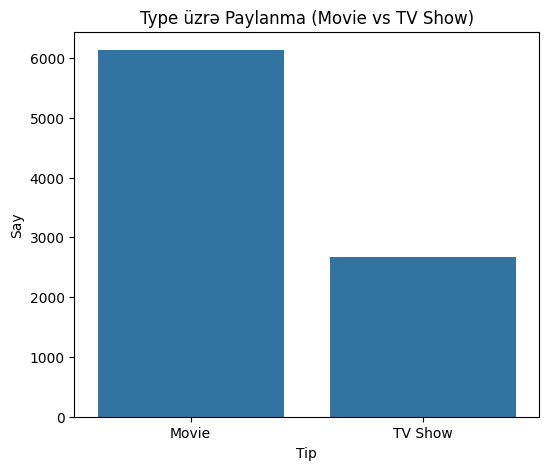

In [25]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="type")
plt.title("Type üzrə Paylanma (Movie vs TV Show)")
plt.xlabel("Tip")
plt.ylabel("Say")
plt.show()

## Country

## Insight
- United States Netflix-də ən böyük paya sahibdir.
- India və United Kingdom sonra gəlir.
- Netflix-də olan film və serialların böyük hissəsi çox sayda ölkədən yox, əsasən bir neçə ölkədən gəlir.
- country sütununda ~830 missing value var idi, "Unknown" ilə dolduruldu.
- bu da metadata-nın tam olmadığını göstərir.

In [26]:
df["country"].value_counts().head(10)

country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [27]:
df["country"].value_counts().tail(10)

country
Germany, United States, United Kingdom, Canada                  1
Canada, India, Thailand, United States, United Arab Emirates    1
United States, East Germany, West Germany                       1
France, Netherlands, South Africa, Finland                      1
Egypt, Austria, United States                                   1
Russia, Spain                                                   1
Croatia, Slovenia, Serbia, Montenegro                           1
Japan, Canada                                                   1
United States, France, South Korea, Indonesia                   1
United Arab Emirates, Jordan                                    1
Name: count, dtype: int64

In [28]:
df["country"].isnull().sum()

np.int64(830)

In [29]:
df["country"] = df["country"].fillna("Unknown")

In [30]:
top_countries = df[df["country"] != "Unknown"]["country"].value_counts().head(10)

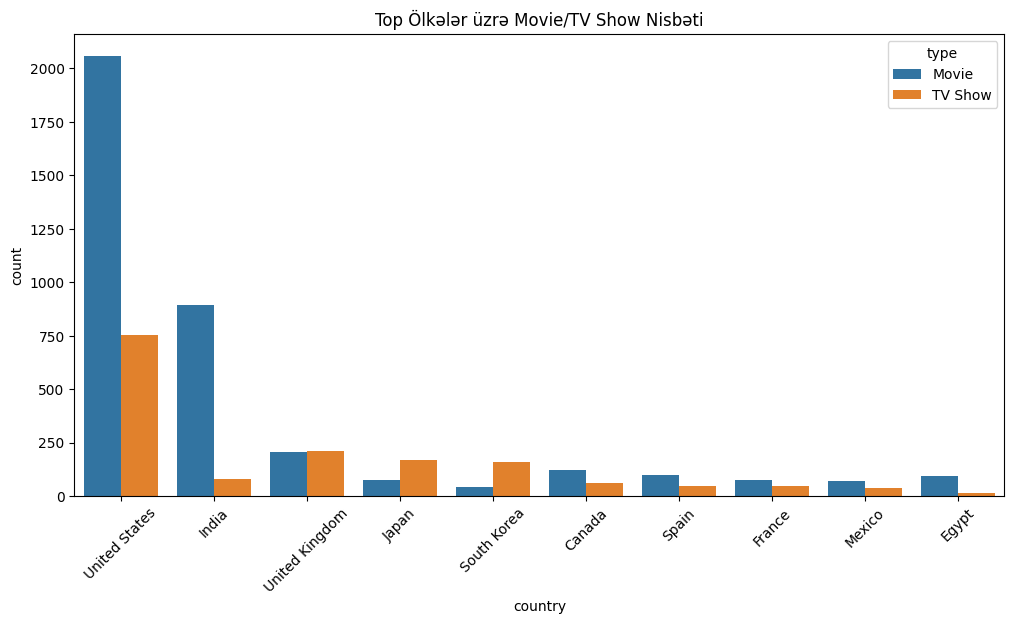

In [31]:
plt.figure(figsize=(12,6))
sns.countplot(data=df[df["country"].isin(top_countries.index)], 
              x="country", hue="type", order=top_countries.index)
plt.title("Top Ölkələr üzrə Movie/TV Show Nisbəti")
plt.xticks(rotation=45)
plt.show()

## Rating

## Insight

- `Rating` sütununda bəzi missing və uyğunsuz dəyərlər aşkar edildi. Missing dəyərlər dataset-dəki bütün sətirləri qorumaq üçün "Not Rated" ilə əvəz edildi. Bundan əlavə, səhvən rating sütununda yerləşən `duration` dəyərləri (məsələn, "66 min", "74 min", "84 min") düzəldilərək uyğun olaraq `duration` sütununa köçürüldü.
- `Rating` analizi göstərir ki, TV-MA Netflix-də ən çox rast gəlinən reytinqdir. Bu, Netflix məzmununun əhəmiyyətli bir hissəsinin yetkin (böyük yaşlı) auditoriyaya yönəldiyini göstərir.
- Qrafik göstərir ki, Netflix-də ən geniş yayılmış reytinqlər TV-MA və TV-14-dür, bu da platformanın əsasən yeniyetmə və böyüklərə yönəldiyini göstərir. Bundan əlavə, filmlər əksər reytinq kateqoriyalarında üstünlük təşkil etdiyi halda, TV-Y və TV-Y7 kimi uşaq reytinqlərində TV Show-ların sayı daha çoxdur.

In [32]:
df["rating"].isnull().sum()

np.int64(4)

In [33]:
df["rating"] = df["rating"].fillna("Not Rated")

In [34]:
df["rating"].value_counts()

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64

In [35]:
df[df["rating"].isin(["66 min", "74 min", "84 min"])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...,2016


In [36]:
mask = df["rating"].isin(["66 min", "74 min", "84 min"])
df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = "Not Rated"

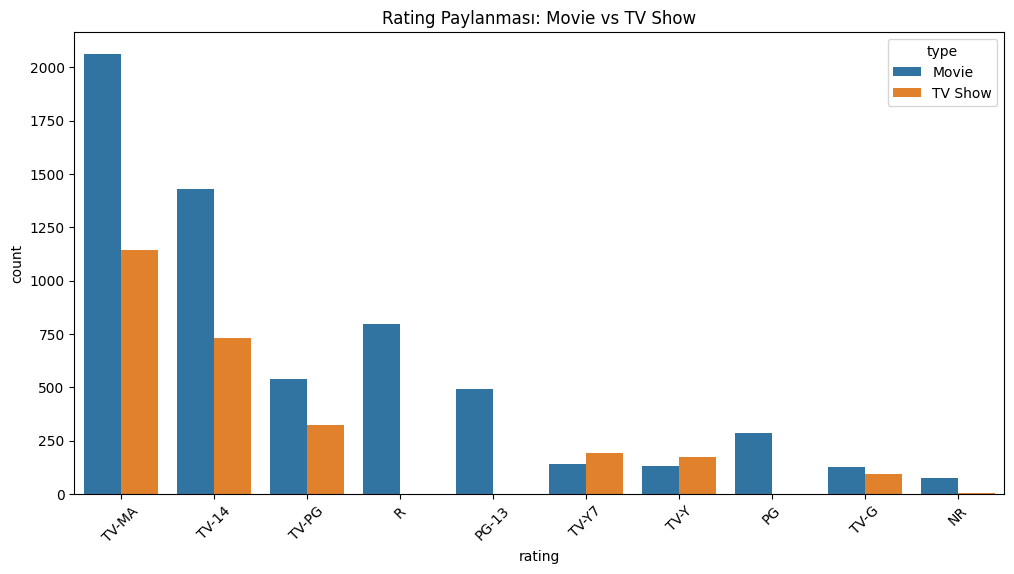

In [37]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="rating", hue="type", 
              order=df["rating"].value_counts().index[:10])
plt.title("Rating Paylanması: Movie vs TV Show")
plt.xticks(rotation=45)
plt.show()

## Duration

## Insight
- Movie duration analizi göstərir ki, Netflix-də filmlərin böyük hissəsi 90–120 dəqiqə arasındadır. Bu, platformada orta uzunluqlu filmlərin daha çox üstünlük təşkil etdiyini göstərir.
- TV Show duration analizi göstərir ki, Netflix-də serialların böyük hissəsi yalnız 1 sezondan ibarətdir. Bu, platformada uzunmüddətli seriallardan daha çox mini-serial və qısa formatlı məzmunun üstünlük təşkil etdiyini göstərir.

In [38]:
df["duration"].isnull().sum()

np.int64(0)

In [39]:
#Movie

In [40]:
df[df["type"] == "Movie"]["duration"].value_counts().head(10)

duration
90 min     152
97 min     146
94 min     146
93 min     146
91 min     144
95 min     137
96 min     130
92 min     129
102 min    122
98 min     120
Name: count, dtype: int64

In [41]:
movies = df[df["type"] == "Movie"].copy()

In [42]:
movies["duration_min"] = movies["duration"].str.replace(" min", "").astype(int)

In [43]:
movies["duration_min"].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

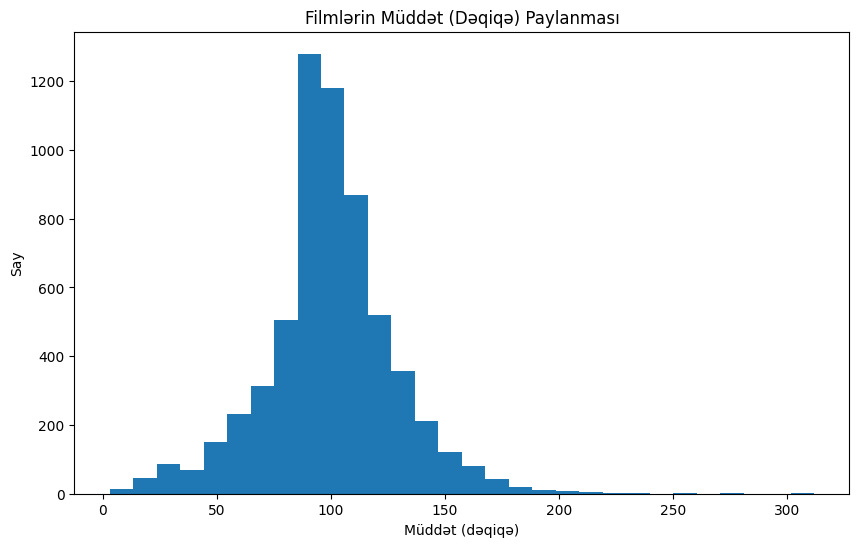

In [44]:
plt.figure(figsize=(10,6))
movies["duration_min"].plot(kind="hist", bins=30)
plt.title("Filmlərin Müddət (Dəqiqə) Paylanması")
plt.xlabel("Müddət (dəqiqə)")
plt.ylabel("Say")
plt.show()

In [45]:
df[df["type"] == "TV Show"]["duration"].value_counts()

duration
1 Season      1793
2 Seasons      421
3 Seasons      198
4 Seasons       94
5 Seasons       64
6 Seasons       33
7 Seasons       23
8 Seasons       17
9 Seasons        9
10 Seasons       6
13 Seasons       2
12 Seasons       2
15 Seasons       2
17 Seasons       1
11 Seasons       1
Name: count, dtype: int64

In [46]:
#TV Show

In [47]:
shows = df[df["type"] == "TV Show"].copy()

In [48]:
shows["season_count"] = (
    shows["duration"]
    .str.replace(" Seasons","")
    .str.replace(" Season", "")
    .astype(int)
)

In [49]:
shows["season_count"].describe()

count    2666.000000
mean        1.751313
std         1.550176
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: season_count, dtype: float64

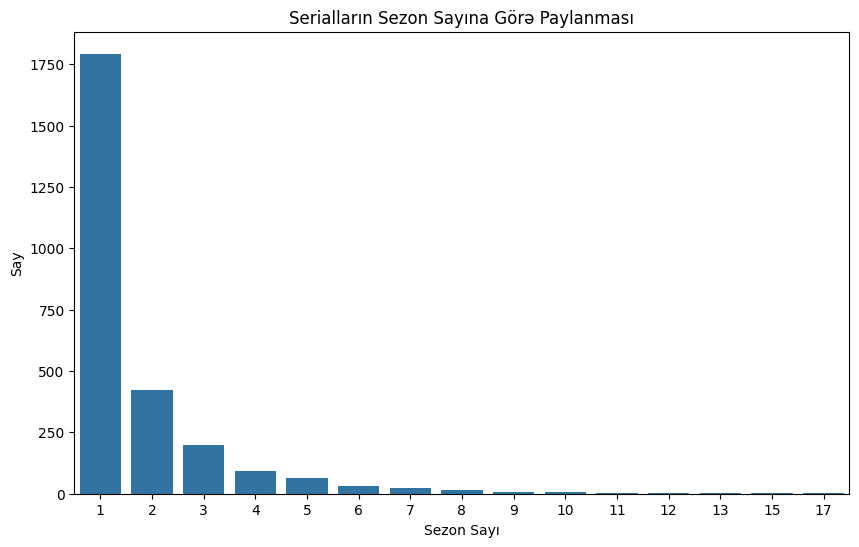

In [50]:
plt.figure(figsize=(10,6))
sns.countplot(data=shows, x="season_count")
plt.title("Serialların Sezon Sayına Görə Paylanması")
plt.xlabel("Sezon Sayı")
plt.ylabel("Say")
plt.show()

In [51]:
#Outliers
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"Sütun: {column}")
    print(f"Lower Limit: {lower}")
    print(f"Upper Limit: {upper}")
    print(f"Outlier sayı: {len(outliers)}")

    return outliers

In [52]:
movie_outliers = detect_outliers(movies, "duration_min")

Sütun: duration_min
Lower Limit: 46.5
Upper Limit: 154.5
Outlier sayı: 450


In [53]:
show_outliers = detect_outliers(shows, "season_count")

Sütun: season_count
Lower Limit: -0.5
Upper Limit: 3.5
Outlier sayı: 254


## Insight

- IQR metoduna əsasən `duration_min` sütununda 450 outlier aşkar edilmişdir. Normal film müddəti 46.5–154.5 dəqiqə aralığında olsa da, bu sərhədlərdən kənarda qalan filmlər çox qısa və ya çox uzun müddətə malikdir. Bu outlier-lər məlumat səhvi deyil, xüsusi formatlı (məsələn, qısametrajlı və ya çox uzun) filmləri təmsil edə bilər.

- `season_count` sütununda IQR metodu ilə 254 outlier müəyyən edilmişdir. Əksər TV Show-lar 1–3 mövsüm arasında olduğu halda, 3.5 mövsümdən çox olan seriallar outlier kimi qiymətləndirilmişdir. Bu nəticə Netflix kataloqunda əsasən qısa serialların üstünlük təşkil etdiyini, uzunmüddətli serialların isə nisbətən az olduğunu göstərir.

## Listed_in

## Insight
Drama Netflix-də ən çox rast gəlinən janrdır. Bu, platformada dramatik hekayə anlatımının əsas və üstünlük təşkil edən məzmun növü olduğunu göstərir.

In [54]:
df["listed_in"].isnull().sum()

np.int64(0)

In [55]:
df["listed_in"].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

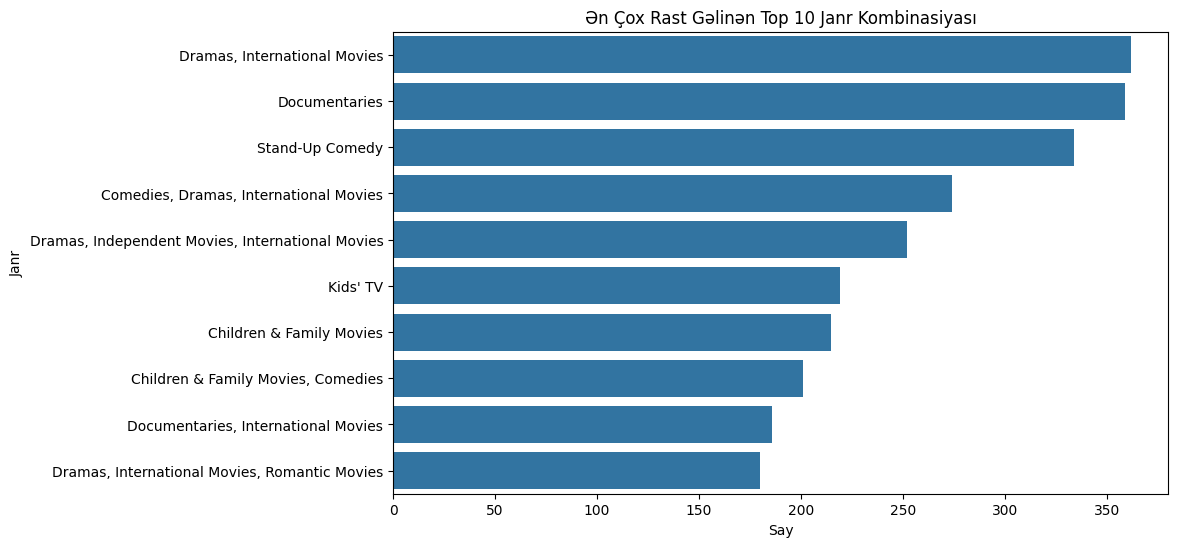

In [56]:
top_genres = df["listed_in"].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Ən Çox Rast Gəlinən Top 10 Janr Kombinasiyası")
plt.xlabel("Say")
plt.ylabel("Janr")
plt.show()

## STATISTIKA

In [57]:
# Korrelyasiya

`Duration_min` və `Release_year` arasında zəif mənfi əlaqə (r = -0.206) müşahidə olundu. Bu, yeni buraxılan kontentin orta hesabla daha qısa olma tendensiyası göstərdiyini bildirir.

In [58]:
movies[["duration_min", "release_year"]].corr()

,duration_min,release_year
duration_min,1.000000,-0.206305
release_year,-0.206305,1.000000


In [59]:
#Chi-square

Chi-square testi göstərdi ki, `type` və `rating` dəyişənləri arasında statistik əhəmiyyətli əlaqə mövcuddur (p < 0.05). Bu, Movies və TV Shows-un rating paylanmalarının bir-birindən əhəmiyyətli dərəcədə fərqləndiyini göstərir.

In [60]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df["type"], df["rating"])
chi2, p_value, dof, expected = chi2_contingency(table)

In [61]:
p_value

np.float64(4.336704571723739e-214)

In [62]:
if p_value < 0.05:
    print("There is a statistically significant difference in rating distribution between Movies and TV Shows.")
else:
    print("No statistically significant difference was found in rating distribution between Movies and TV Shows.")

There is a statistically significant difference in rating distribution between Movies and TV Shows.


In [63]:
# Cramér's V — chi-square nəticəsinin effect size (əlaqənin gücü) ölçüsü
n = table.sum().sum()
min_dim = min(table.shape) - 1
cramers_v = np.sqrt((chi2 / n) / min_dim)
print("Cramer's V:", round(cramers_v, 3))

Cramer's V: 0.345


## Insight

Chi-square testi `type` və `rating` arasında statistik əhəmiyyətli əlaqə göstərsə də (p < 0.05), Cramér's V dəyəri əlaqənin **gücünü** ölçür (0 = əlaqə yoxdur, 1 = güclü əlaqə). Adətən 0.1-dən aşağı dəyərlər zəif, 0.1-0.3 arası orta-zəif əlaqəni göstərir. Yəni statistik əhəmiyyətlilik böyük sample ölçüsündən qaynaqlana bilər, amma real təsir (effect size) məhdud ola bilər.

## Yekun Xülasə

Bu analiz Netflix kataloqunun strukturunu bir neçə istiqamətdən araşdırdı:

1. **Data keyfiyyəti**: `director`, `cast`, `country`, `rating`, `date_added` sütunlarında missing value-lar aşkarlanıb məqsədəuyğun şəkildə təmizləndi; 14 sətirdə `date_added` və `release_year` arasında məntiqi uyğunsuzluq tapıldı.
2. **Kateqoriya strukturu**: Movie-lər dataset-in çoxluğunu təşkil edir (~69.7%), United States əsas istehsalçı ölkədir, Drama ən çox rast gəlinən janrdır.
3. **Zaman trendi**: Netflix-ə əlavə olunan məzmun 2016-2019 arası sürətlə artıb, TV Show-ların payı da bu müddətdə yüksəlib.
4. **Statistik əlaqələr**: `duration_min` ilə `release_year` arasında zəif mənfi korrelyasiya (r ≈ -0.206); `type` və `rating` arasında statistik əhəmiyyətli, lakin (Cramér's V-yə görə) nisbətən zəif-orta gücdə əlaqə var.
